# 19 — Boxplots of Solution Quality Across Runs

**Maps to:** `report/Chapters/Task4.tex` §`T4:Boxplots`.  
**Ticket:** TICKET-19.

Final tour length per configuration / per constraint-handling strategy. Output: `results/figures/boxplot_<axis>.pdf`.

**Import & Setup**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
plt.rcParams.update({
    'figure.dpi'                   : 150,
    'savefig.dpi'                  : 300,
    'font.size'                    : 10,
    'axes.titlesize'               : 12,
    'axes.labelsize'               : 11,
    'legend.fontsize'              : 9,
    'figure.figsize'               : (8, 5),
    'figure.constrained_layout.use': True,
})

FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OPTIMAL = 21282

**Load Data**

In [3]:
results = pd.read_csv(Path('../results/compare.csv'))

print(f"Shape     : {results.shape}")
print(f"Columns   : {list(results.columns)}")
print(f"Strategies: {results['strategy'].unique()}")
print(f"Runs per strategy:")
print(results['strategy'].value_counts().to_string())

Shape     : (60, 5)
Columns   : ['strategy', 'seed', 'best_fitness', 'mean_fitness', 'diversity']
Strategies: <StringArray>
['repair', 'no_repair']
Length: 2, dtype: str
Runs per strategy:
strategy
repair       30
no_repair    30


**Boxplot: Per Constraint-Handling Strategy**

This boxplot compares the distribution of final tour lengths across 30 independent runs for each constraint-handling strategy. A lower tour length indicates better solution quality. The known optimal tour length of kroA100 (21,282) is shown as a reference line.

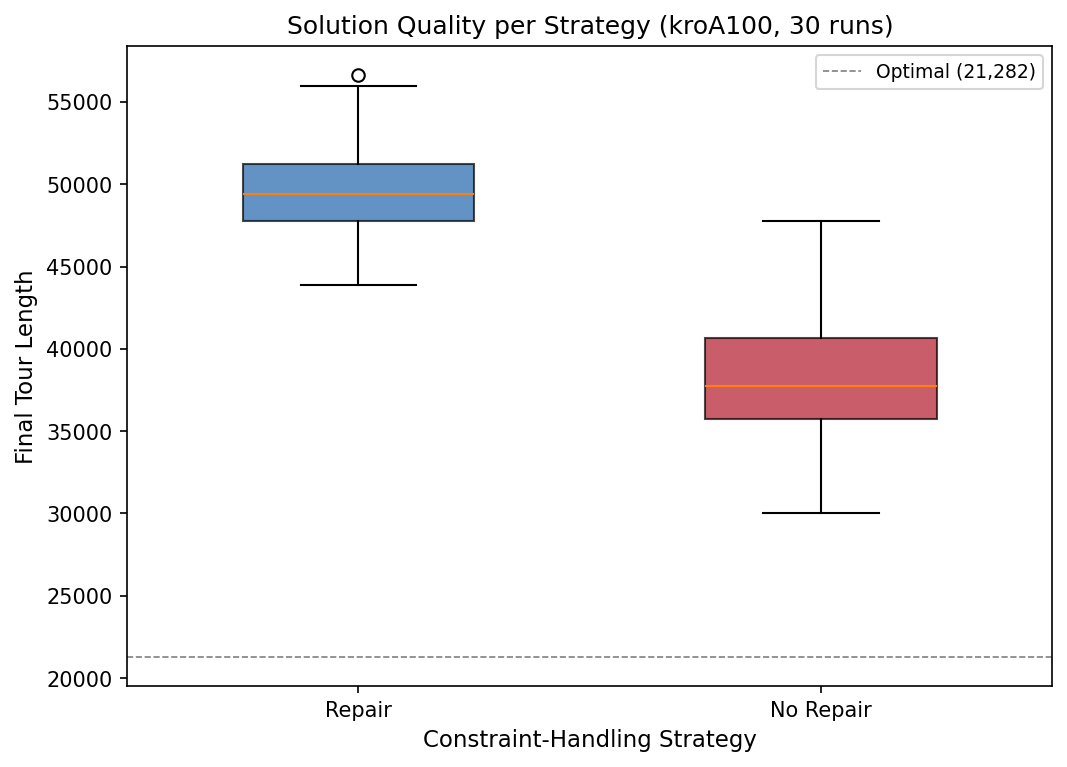

Saved: ..\results\figures\boxplot_strategy.png


In [4]:
STRATEGY_STYLE = {
    'repair'   : {'color': '#2166ac', 'label': 'Repair'},
    'no_repair': {'color': '#b2182b', 'label': 'No Repair'},
}

fig, ax     = plt.subplots(figsize=(7, 5))
strategies  = ['repair', 'no_repair']
data_groups = [
    results[results['strategy'] == s]['best_fitness'].values
    for s in strategies
]
labels = [STRATEGY_STYLE[s]['label'] for s in strategies]
colors = [STRATEGY_STYLE[s]['color'] for s in strategies]

bp = ax.boxplot(
    data_groups,
    patch_artist=True,
    tick_labels=labels,
    widths=0.5,
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(
    y=OPTIMAL,
    color='gray', linestyle='--',
    linewidth=0.8,
    label=f'Optimal ({OPTIMAL:,})'
)

ax.set_xlabel('Constraint-Handling Strategy')
ax.set_ylabel('Final Tour Length')
ax.set_title('Solution Quality per Strategy (kroA100, 30 runs)')
ax.legend(loc='upper right')

path = FIGURES_DIR / 'boxplot_strategy.png'
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

The boxplot above compares the distribution of final tour lengths across 30 independent runs for both constraint-handling strategies on kroA100.

The repair strategy produces a median tour length of approximately 49,500, with a relatively narrow interquartile range indicating consistent performance across runs. One outlier is observed at approximately 57,000, suggesting that occasional runs converge to a significantly worse solution.

The no-repair strategy produces a lower median tour length of approximately 38,000, with a wider interquartile range reflecting higher variability across runs. However, this result is misleading. Since infeasible chromosomes are allowed to survive, the tour length is computed on invalid tours that visit some cities more than once and skip others entirely, which artificially reduces the measured distance.

Both strategies remain considerably above the known optimal tour length of 21,282, shown as the dashed reference line. This gap highlights the importance of further optimisation through parameter tuning and improved crossover operators.

**Statistical Test: Wilcoxon Signed-Rank Test**

A Wilcoxon signed-rank test is used to determine whether the difference in final tour length between the repair and no-repair strategies is statistically significant.

The null hypothesis states that there is no difference in median final tour length between both strategies. A significance level of 0.05 is used.

In [5]:
repair_vals    = results[results['strategy'] == 'repair'].sort_values('seed')['best_fitness'].values
no_repair_vals = results[results['strategy'] == 'no_repair'].sort_values('seed')['best_fitness'].values

stat, p_value  = stats.wilcoxon(repair_vals, no_repair_vals)

print('Wilcoxon Signed-Rank Test')
print('=' * 45)
print(f'Test statistic : {stat:.2f}')
print(f'p-value        : {p_value:.6f}')
print(f'α              : 0.05')
print(f'Reject H₀      : {"Yes" if p_value < 0.05 else "No"}')
print()
if p_value < 0.05:
    print('The difference between strategies is statistically significant.')
else:
    print('No statistically significant difference was found.')

Wilcoxon Signed-Rank Test
Test statistic : 0.00
p-value        : 0.000000
α              : 0.05
Reject H₀      : Yes

The difference between strategies is statistically significant.


The Wilcoxon signed-rank test confirms that the difference in final tour length between the repair and no-repair strategies is statistically significant, with a p-value of approximately 0.000000, which is well below the significance level of 0.05. The null hypothesis is therefore rejected.

The test statistic of 0.00 indicates that in all 30 paired runs, the no-repair strategy consistently produced a lower recorded tour length than the repair strategy. However, as noted above, this result reflects the artificial advantage of the no-repair strategy rather than genuine solution quality. Infeasible tours visit fewer unique cities, which reduces the measured distance without producing a valid solution.

Therefore, while the difference is statistically significant, it should be interpreted with caution. The repair strategy produces valid tours in all runs, making it the more reliable approach for solving the TSP correctly.

**Summary Statistics**

Per-strategy summary of final tour length across 30 runs. Gap is computed relative to the known optimal tour length of kroA100 (21,282).

In [7]:
summary          = results.groupby('strategy')['best_fitness'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).round(2)
summary['gap_%'] = ((summary['mean'] - OPTIMAL) / OPTIMAL * 100).round(1)

print('Summary Statistics: Final Tour Length')
print('=' * 65)
print(summary.to_string())

Summary Statistics: Final Tour Length
           count      mean      std       min    median       max  gap_%
strategy                                                                
no_repair     30  38194.39  4036.48  30034.08  37750.48  47741.29   79.5
repair        30  49777.84  3186.86  43890.51  49406.18  56629.20  133.9


The summary statistics confirm the observed difference between both strategies across 30 independent runs on kroA100.

The repair strategy produces a mean final tour length of 49,777.84 with a standard deviation of 3,186.86, indicating relatively consistent performance across runs. The gap from the known optimal tour length of 21,282 is 133.9%, suggesting that the GA with repair has not yet converged close to the optimal solution under the current configuration.

The no-repair strategy records a lower mean tour length of 38,194.39 with a higher standard deviation of 4,036.48, reflecting greater variability across runs. The gap from the optimal is 79.5%. However, as discussed previously, this lower value is misleading as it is computed on infeasible tours that visit duplicate cities and skip others, which artificially reduces the measured distance.

The repair strategy produces valid tours in all 30 runs, making it the correct and reliable approach for the TSP. The no-repair strategy, despite appearing numerically better, does not produce valid solutions and therefore cannot be considered a meaningful comparison in terms of actual solution quality.